# 🎓 Adaptive Meta-Cognitive Hybrid AI Framework
## Student Dropout & Placement Risk Prediction

**College ML Project** | Logistic Regression · Decision Tree · Random Forest · XGBoost · Voting Ensembles

---
### Table of Contents
1. Setup & Dataset Generation
2. Data Preprocessing
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Model Training (4 Base + 2 Voting)
6. Model Comparison & Evaluation
7. Meta-Cognitive Evaluation Module
8. Single Student Prediction Demo
9. Recommendation Engine


## 1. 📦 Setup & Dataset Generation

In [1]:
# Install required libraries (uncomment if needed)
# !pip install scikit-learn xgboost plotly pandas numpy seaborn matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)
from xgboost import XGBClassifier
import joblib, os

np.random.seed(42)
print("✅ Libraries loaded")


✅ Libraries loaded


In [2]:
# ── Generate Synthetic Dataset ──────────────────────────────────────────────
N = 800

attendance = np.clip(np.random.normal(75, 15, N), 30, 100)
cgpa       = np.clip(np.random.normal(7.2, 1.1, N), 4.0, 10.0)
sem_gpa    = np.clip(cgpa + np.random.normal(0, 0.4, N), 4.0, 10.0)
int_marks  = np.clip(cgpa * 9 + np.random.normal(0, 5, N), 20, 90)
backlogs   = np.random.choice([0,1,2,3,4,5], N, p=[0.50,0.22,0.13,0.08,0.05,0.02])

coding    = np.clip(np.random.normal(60, 20, N), 0, 100)
comm      = np.clip(np.random.normal(62, 18, N), 0, 100)
tech      = np.clip(np.random.normal(58, 20, N), 0, 100)
aptitude  = np.clip(np.random.normal(65, 15, N), 0, 100)
english   = np.clip(np.random.normal(63, 17, N), 0, 100)

internship     = np.random.choice([0, 1], N, p=[0.45, 0.55])
projects       = np.random.choice([0, 1, 2, 3], N, p=[0.20, 0.35, 0.30, 0.15])
certifications = np.random.choice([0, 1, 2, 3], N, p=[0.25, 0.40, 0.25, 0.10])
gender = np.random.choice(["Male","Female","Other"], N, p=[0.50,0.47,0.03])
branch = np.random.choice(["CSE","ECE","ME","CE","IT"], N, p=[0.30,0.20,0.20,0.15,0.15])
year   = np.random.choice([1,2,3,4], N, p=[0.20,0.25,0.28,0.27])

# Smooth, calibrated dropout logic
dropout_score = (
    -0.08*(attendance-75) - 0.55*(cgpa-7.0)
    + 0.35*backlogs - 0.008*((coding+tech)/2-60)
    + np.random.normal(0,0.6,N) - 0.5
)
dropout_risk = (1/(1+np.exp(-dropout_score)) > 0.5).astype(int)

# Realistic placement logic (~65% placement rate)
place_score = (
    0.35*(cgpa-7.0) + 0.025*(coding-60) + 0.015*(comm-60) + 0.015*(tech-60)
    + 0.70*internship + 0.20*projects + 0.12*certifications
    + 0.010*(aptitude-65) - 0.20*backlogs
    + np.random.normal(0,0.8,N) + 0.2
)
placement = (1/(1+np.exp(-place_score)) > 0.5).astype(int)

df = pd.DataFrame({
    "student_id": [f"STU{i:04d}" for i in range(1,N+1)],
    "gender":gender, "branch":branch, "year":year,
    "cgpa":cgpa.round(2), "attendance":attendance.round(1),
    "sem_gpa":sem_gpa.round(2), "internal_marks":int_marks.round(1),
    "backlogs":backlogs, "coding_skill":coding.round(1),
    "communication_skill":comm.round(1), "technical_skill":tech.round(1),
    "aptitude_score":aptitude.round(1), "english_proficiency":english.round(1),
    "internship":internship, "projects":projects, "certifications":certifications,
    "dropout_risk":dropout_risk, "placement":placement,
})

# Introduce 5% missing values
for col in ["sem_gpa","internal_marks","english_proficiency","certifications"]:
    mask = np.random.rand(N) < 0.05
    df.loc[mask, col] = np.nan

print(f"Dataset: {df.shape[0]} students × {df.shape[1]} features")
print(f"Dropout Rate  : {df['dropout_risk'].mean():.1%}")
print(f"Placement Rate: {df['placement'].mean():.1%}")
df.head()


Dataset: 800 students × 19 features
Dropout Rate  : 43.5%
Placement Rate: 75.0%


,student_id,gender,branch,year,cgpa,attendance,sem_gpa,internal_marks,backlogs,coding_skill,communication_skill,technical_skill,aptitude_score,english_proficiency,internship,projects,certifications,dropout_risk,placement
0,STU0001,Male,IT,3,8.23,82.5,8.16,70.5,4,59.1,46.0,76.5,63.7,53.5,1,3,1.0,0,1
1,STU0002,Female,IT,3,6.63,72.9,7.18,60.6,1,63.7,75.9,56.2,93.2,63.6,0,2,1.0,0,0
2,STU0003,Male,CSE,3,7.31,84.7,7.05,63.0,2,46.6,68.4,54.4,72.8,82.3,1,3,0.0,0,1
3,STU0004,Female,CSE,1,6.69,97.8,6.37,58.9,1,83.4,84.7,71.1,60.1,69.8,1,1,1.0,0,1
4,STU0005,Male,ECE,4,6.72,71.5,6.53,68.9,2,36.5,50.0,77.3,43.6,68.3,1,2,1.0,1,1


## 2. 🔧 Data Preprocessing

In [3]:
# ── Missing Value Check ─────────────────────────────────────────────────────
print("Missing values before cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# ── Clean ───────────────────────────────────────────────────────────────────
df_clean = df.copy()
df_clean.drop_duplicates(inplace=True)

num_cols = df_clean.select_dtypes(include=np.number).columns
for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

cat_cols = df_clean.select_dtypes(include="object").columns
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("\nMissing values after cleaning:", df_clean.isnull().sum().sum())

# ── Label Encoding ──────────────────────────────────────────────────────────
for col in ["gender","branch"]:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

print("\nData types after encoding:")
print(df_clean.dtypes.value_counts())
df_clean.describe().round(2)


Missing values before cleaning:
sem_gpa                39
internal_marks         34
english_proficiency    32
certifications         36
dtype: int64

Missing values after cleaning: 0

Data types after encoding:
float64    10
int64       8
str         1
Name: count, dtype: int64


,gender,branch,year,cgpa,attendance,sem_gpa,internal_marks,backlogs,coding_skill,communication_skill,technical_skill,aptitude_score,english_proficiency,internship,projects,certifications,dropout_risk,placement
count,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.0,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00
mean,0.57,1.95,2.64,7.30,74.56,7.30,65.59,1.0,58.84,61.30,57.23,64.49,62.95,0.56,1.44,1.20,0.44,0.75
std,0.56,1.33,1.12,1.10,14.02,1.13,10.84,1.3,19.57,17.43,20.03,15.36,17.10,0.50,0.97,0.93,0.50,0.43
min,0.00,0.00,1.00,4.00,30.00,4.00,32.10,0.0,0.00,4.80,0.00,24.40,0.30,0.00,0.00,0.00,0.00,0.00
25%,0.00,1.00,2.00,6.56,64.50,6.53,58.88,0.0,46.15,49.48,43.78,53.80,51.80,0.00,1.00,1.00,0.00,0.75
50%,1.00,2.00,3.00,7.28,75.20,7.30,65.50,0.0,59.35,61.70,57.15,64.30,62.95,1.00,1.00,1.00,0.00,1.00
75%,1.00,3.00,4.00,8.01,84.40,8.01,72.50,2.0,72.12,73.53,70.95,75.53,74.55,1.00,2.00,2.00,1.00,1.00
max,2.00,4.00,4.00,10.00,100.00,10.00,90.00,5.0,100.00,100.00,100.00,100.00,100.00,1.00,3.00,3.00,1.00,1.00


## 3. 📊 Exploratory Data Analysis

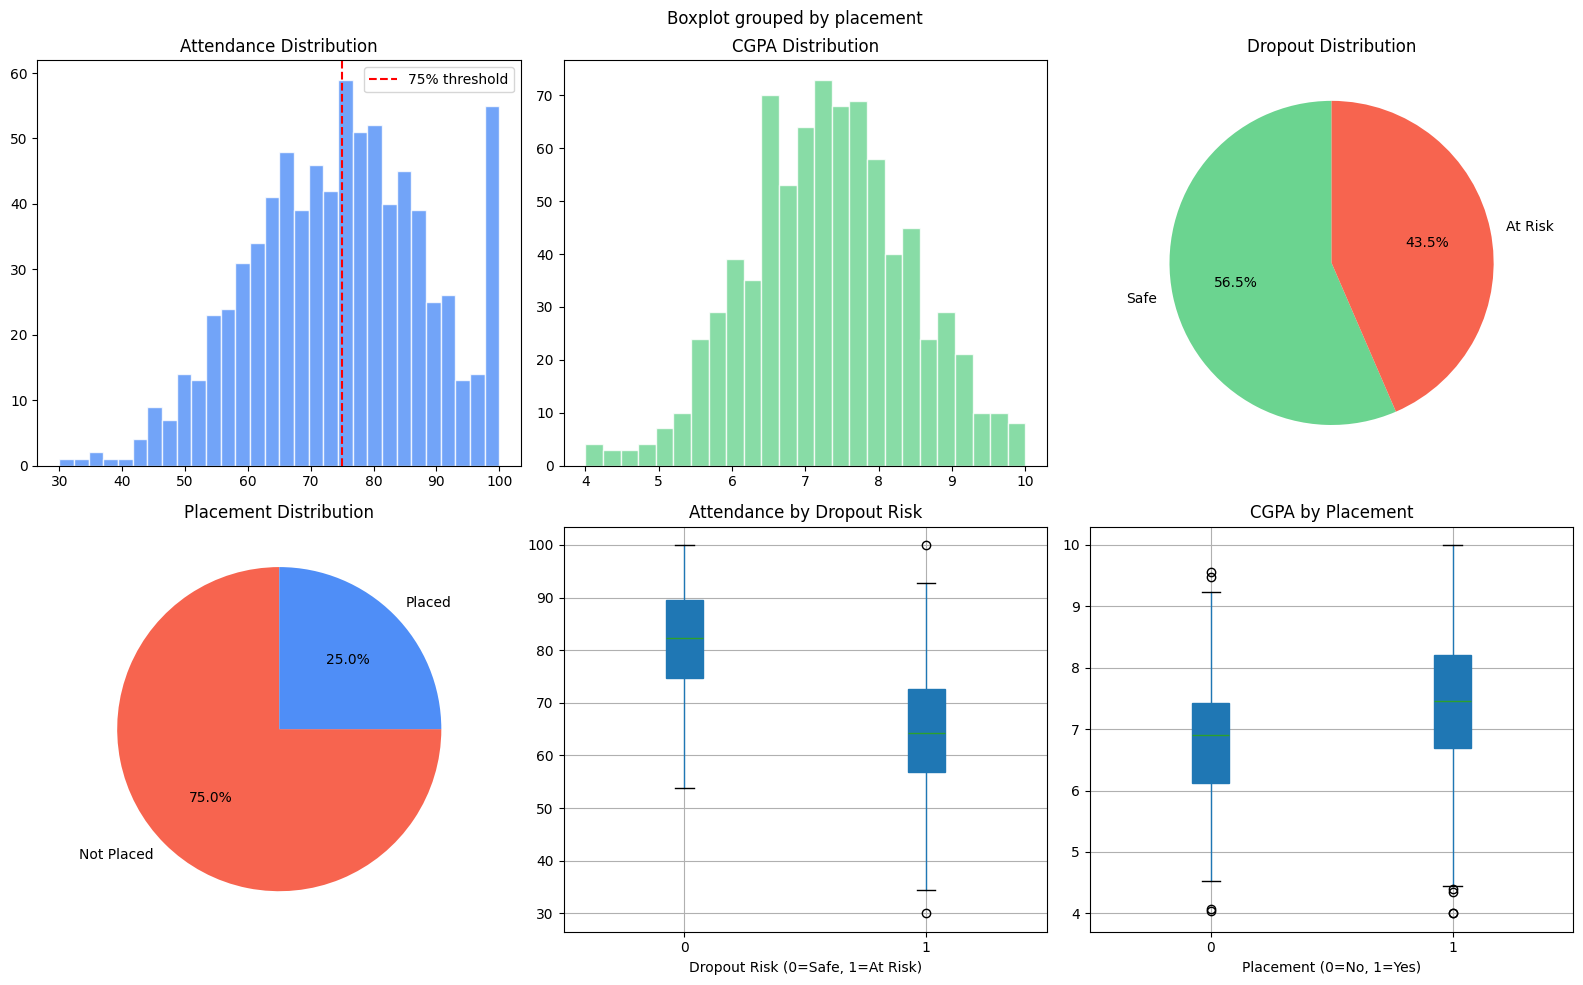

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Exploratory Data Analysis", fontsize=16, fontweight='bold')

# Attendance distribution
axes[0,0].hist(df_clean['attendance'], bins=30, color='#4F8EF7', edgecolor='white', alpha=0.8)
axes[0,0].axvline(75, color='red', linestyle='--', label='75% threshold')
axes[0,0].set_title('Attendance Distribution'); axes[0,0].legend()

# CGPA distribution
axes[0,1].hist(df_clean['cgpa'], bins=25, color='#6BD490', edgecolor='white', alpha=0.8)
axes[0,1].set_title('CGPA Distribution')

# Dropout distribution
counts = df_clean['dropout_risk'].value_counts()
axes[0,2].pie(counts, labels=['Safe','At Risk'], colors=['#6BD490','#F7644F'],
              autopct='%1.1f%%', startangle=90)
axes[0,2].set_title('Dropout Distribution')

# Placement distribution
counts2 = df_clean['placement'].value_counts()
axes[1,0].pie(counts2, labels=['Not Placed','Placed'], colors=['#F7644F','#4F8EF7'],
              autopct='%1.1f%%', startangle=90)
axes[1,0].set_title('Placement Distribution')

# Attendance vs Dropout (box plot)
df_clean.boxplot(column='attendance', by='dropout_risk', ax=axes[1,1],
                 patch_artist=True)
axes[1,1].set_title('Attendance by Dropout Risk')
axes[1,1].set_xlabel('Dropout Risk (0=Safe, 1=At Risk)')

# CGPA vs Placement
df_clean.boxplot(column='cgpa', by='placement', ax=axes[1,2], patch_artist=True)
axes[1,2].set_title('CGPA by Placement')
axes[1,2].set_xlabel('Placement (0=No, 1=Yes)')

plt.tight_layout()
plt.show()


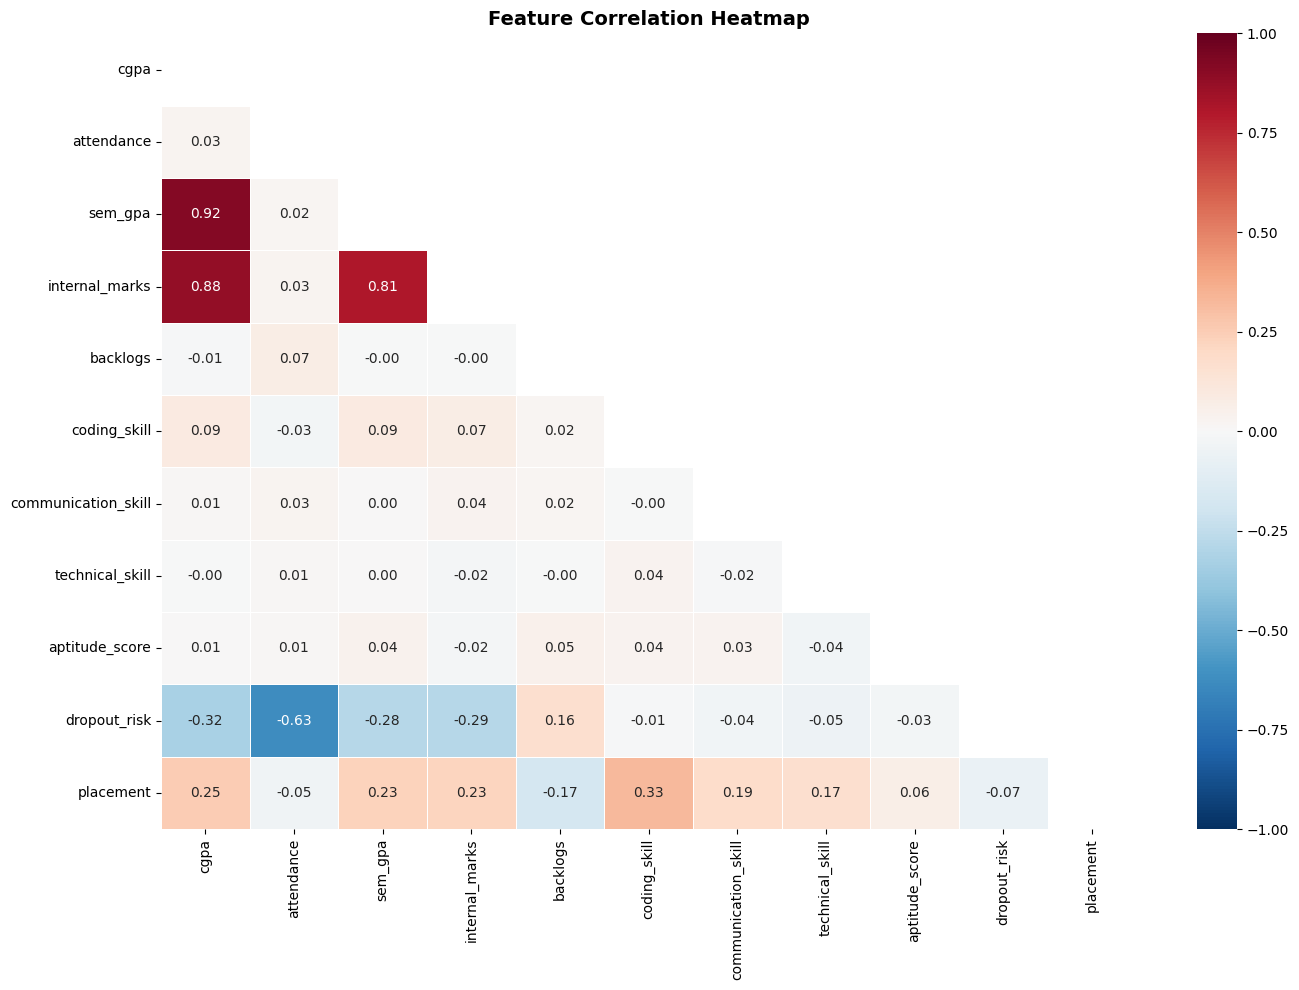

In [5]:
# Correlation Heatmap
plt.figure(figsize=(14,10))
num_features = ['cgpa','attendance','sem_gpa','internal_marks','backlogs',
                'coding_skill','communication_skill','technical_skill',
                'aptitude_score','dropout_risk','placement']
corr = df_clean[num_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. ⚙️ Feature Engineering

In [6]:
# ── Derived Features ────────────────────────────────────────────────────────

# Academic Consistency: closeness of CGPA and SemGPA, penalised by backlogs
diff = (df_clean['cgpa'] - df_clean['sem_gpa']).abs()
df_clean['academic_consistency'] = np.clip(
    100 - (diff * 10) - (df_clean['backlogs'] * 5), 0, 100
)

# Skill Readiness: average of 5 skill columns + experience bonus
skill_avg = df_clean[['coding_skill','communication_skill','technical_skill',
                        'aptitude_score','english_proficiency']].mean(axis=1)
df_clean['skill_readiness'] = np.clip(
    skill_avg
    + df_clean['internship'] * 5
    + df_clean['projects']   * 3
    + df_clean['certifications'] * 2,
    0, 100
)

# Overall Performance Score: weighted composite
cgpa_norm = df_clean['cgpa'] / 10 * 100
df_clean['overall_performance'] = np.clip(
    0.35 * cgpa_norm
    + 0.25 * df_clean['attendance']
    + 0.20 * df_clean['skill_readiness']
    + 0.10 * df_clean['internship'] * 100
    + 0.10 * df_clean['projects'] * 33.3,
    0, 100
)

print("✅ Engineered features added:")
print(df_clean[['academic_consistency','skill_readiness','overall_performance']].describe().round(2))


✅ Engineered features added:
       academic_consistency  skill_readiness  overall_performance
count                800.00           800.00               800.00
mean                  91.69            70.51                68.72
std                    7.32             9.41                 8.74
min                   60.90            35.74                45.11
25%                   88.18            64.28                62.67
50%                   93.90            70.77                69.41
75%                   97.30            76.86                74.76
max                  100.00            99.02                91.32


## 5. 🤖 Model Training — 4 Base + 2 Voting Ensembles

In [7]:
FEATURE_COLS = [
    'cgpa','attendance','sem_gpa','internal_marks','backlogs',
    'coding_skill','communication_skill','technical_skill',
    'aptitude_score','english_proficiency',
    'internship','projects','certifications',
    'academic_consistency','skill_readiness','overall_performance',
]

X = df_clean[FEATURE_COLS].fillna(df_clean[FEATURE_COLS].median())
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=FEATURE_COLS)

def build_base_models():
    return {
        "Logistic Regression": LogisticRegression(max_iter=1000, C=1.0, random_state=42),
        "Decision Tree":       DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=42),
        "Random Forest":       RandomForestClassifier(n_estimators=150, max_depth=8, random_state=42),
        "XGBoost":             XGBClassifier(n_estimators=150, max_depth=5, learning_rate=0.05,
                                              random_state=42, eval_metric='logloss', verbosity=0),
    }

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall":    recall_score(y_test, y_pred, zero_division=0),
        "F1 Score":  f1_score(y_test, y_pred, zero_division=0),
    }

def train_pipeline(X_scaled, y, label):
    X_tr, X_te, y_tr, y_te = train_test_split(X_scaled, y, test_size=0.2,
                                                random_state=42, stratify=y)
    base = build_base_models()
    trained, results = {}, {}
    for name, model in base.items():
        model.fit(X_tr, y_tr)
        trained[name] = model
        results[name] = evaluate_model(model, X_te, y_te)

    estimators = list(trained.items())
    hard = VotingClassifier(estimators=estimators, voting='hard')
    soft = VotingClassifier(estimators=estimators, voting='soft')
    hard.fit(X_tr, y_tr); trained['Hard Voting'] = hard; results['Hard Voting'] = evaluate_model(hard, X_te, y_te)
    soft.fit(X_tr, y_tr); trained['Soft Voting'] = soft; results['Soft Voting'] = evaluate_model(soft, X_te, y_te)

    best = max(results, key=lambda k: results[k]['F1 Score'])
    print(f"\n{'─'*55}")
    print(f"  {label} — Best Model: ★ {best}")
    print(f"{'─'*55}")
    df_res = pd.DataFrame(results).T.round(4)
    display(df_res.style.highlight_max(axis=0, color='#1a5c1a').highlight_max(subset=['F1 Score'],color='#0a3a0a'))
    return trained, results, best, X_te, y_te

print("Training Dropout Risk models…")
dropout_trained, dropout_results, dropout_best, Xte_d, yte_d = train_pipeline(
    X_scaled, df_clean['dropout_risk'], "DROPOUT RISK"
)

print("\nTraining Placement models…")
placement_trained, placement_results, placement_best, Xte_p, yte_p = train_pipeline(
    X_scaled, df_clean['placement'], "PLACEMENT"
)


Training Dropout Risk models…



───────────────────────────────────────────────────────
  DROPOUT RISK — Best Model: ★ Logistic Regression
───────────────────────────────────────────────────────


,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.843800,0.835800,0.800000,0.817500
Decision Tree,0.793800,0.824600,0.671400,0.740200
Random Forest,0.800000,0.827600,0.685700,0.750000
XGBoost,0.793800,0.813600,0.685700,0.744200
Hard Voting,0.800000,0.865400,0.642900,0.737700
Soft Voting,0.806200,0.809500,0.728600,0.766900



Training Placement models…



───────────────────────────────────────────────────────
  PLACEMENT — Best Model: ★ Logistic Regression
───────────────────────────────────────────────────────


,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.825000,0.853800,0.925000,0.888000
Decision Tree,0.768800,0.837400,0.858300,0.847700
Random Forest,0.800000,0.823500,0.933300,0.875000
XGBoost,0.793800,0.837200,0.900000,0.867500
Hard Voting,0.825000,0.859400,0.916700,0.887100
Soft Voting,0.793800,0.822200,0.925000,0.870600


## 6. 📈 Model Comparison & Evaluation

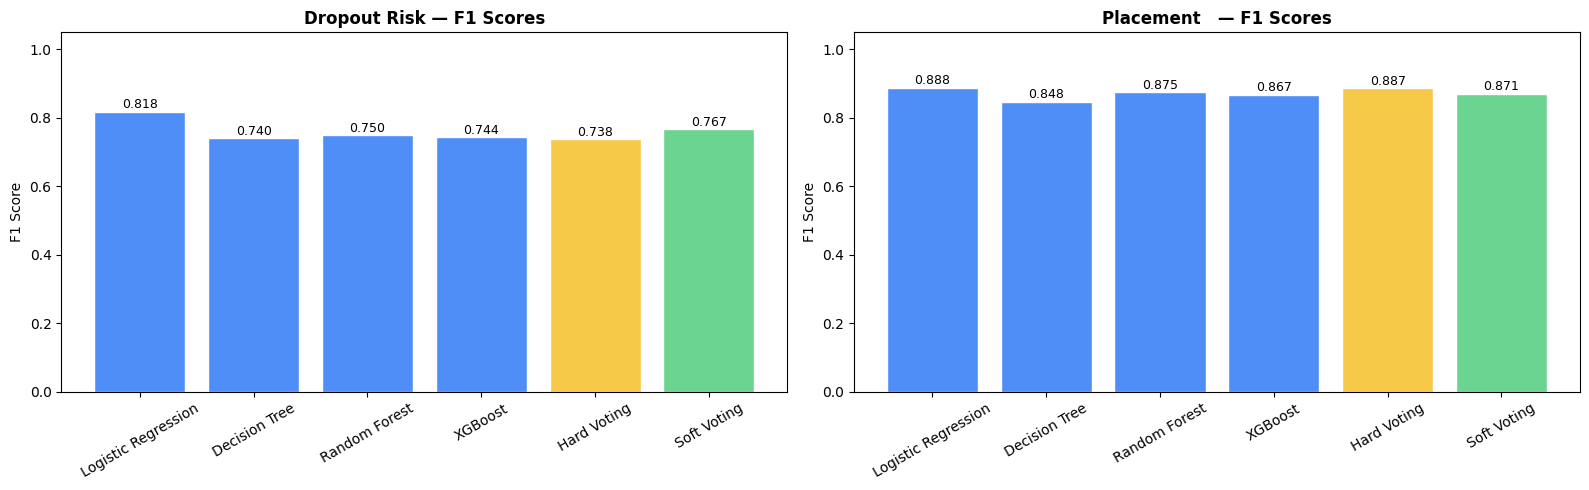

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, results, title in [
    (axes[0], dropout_results,   "Dropout Risk — F1 Scores"),
    (axes[1], placement_results, "Placement   — F1 Scores"),
]:
    names  = list(results.keys())
    f1s    = [results[m]["F1 Score"] for m in names]
    colors = ['#4F8EF7']*4 + ['#F7C948','#6BD490']   # voting in different colour
    bars   = ax.bar(names, f1s, color=colors, edgecolor='white')
    ax.set_ylim(0, 1.05)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel("F1 Score")
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, f1s):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.01,
                f'{val:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


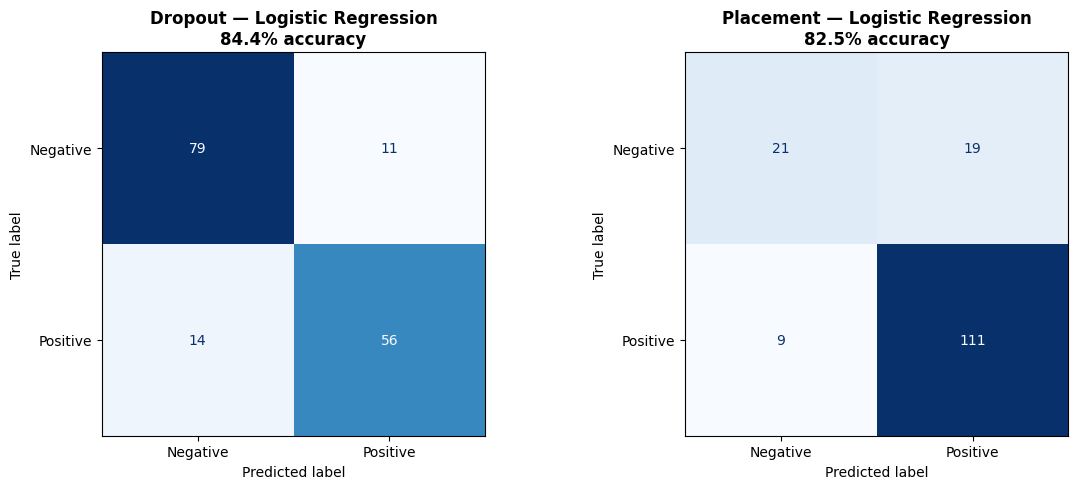

In [9]:
# Confusion Matrices for best models
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, trained, results, best, Xte, yte, title in [
    (axes[0], dropout_trained,   dropout_results,   dropout_best,   Xte_d, yte_d, "Dropout"),
    (axes[1], placement_trained, placement_results, placement_best, Xte_p, yte_p, "Placement"),
]:
    y_pred = trained[best].predict(Xte)
    cm = confusion_matrix(yte, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Negative","Positive"])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{title} — {best}\n{classification_report(yte, y_pred, output_dict=True)['accuracy']:.1%} accuracy",
                 fontweight='bold')

plt.tight_layout()
plt.show()


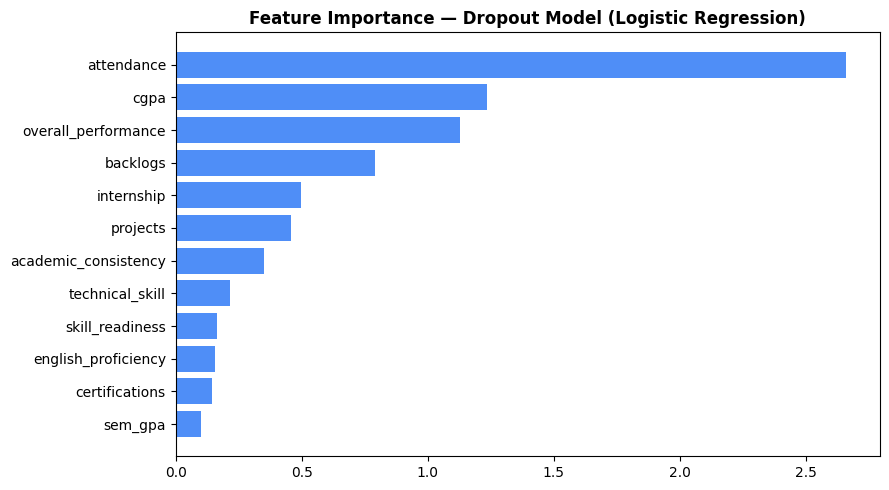

In [10]:
# Feature Importance (best dropout model)
model = dropout_trained[dropout_best]
# Unwrap VotingClassifier if needed
if isinstance(model, VotingClassifier):
    for name, est in model.estimators_:
        if hasattr(est, 'feature_importances_'):
            model = est; break

if hasattr(model, 'feature_importances_'):
    imp = pd.DataFrame({'Feature': FEATURE_COLS, 'Importance': model.feature_importances_})
elif hasattr(model, 'coef_'):
    imp = pd.DataFrame({'Feature': FEATURE_COLS, 'Importance': abs(model.coef_[0])})
else:
    imp = pd.DataFrame({'Feature': FEATURE_COLS, 'Importance': np.ones(len(FEATURE_COLS))})

imp = imp.sort_values('Importance', ascending=True).tail(12)

plt.figure(figsize=(9, 5))
plt.barh(imp['Feature'], imp['Importance'], color='#4F8EF7')
plt.title(f'Feature Importance — Dropout Model ({dropout_best})', fontweight='bold')
plt.tight_layout(); plt.show()


## 7. 🧠 Meta-Cognitive Evaluation Module

This is the **novel contribution** — evaluates the *reliability* of every prediction.

In [11]:
EXPECTED_FEATURES = [
    'cgpa','attendance','sem_gpa','internal_marks','backlogs',
    'coding_skill','communication_skill','technical_skill',
    'aptitude_score','english_proficiency','internship','projects','certifications',
]

def clamp(v):
    return float(np.clip(v, 0, 100))

def prediction_confidence(drop_prob, place_prob):
    margin = (abs(drop_prob-0.5) + abs(place_prob-0.5))  # 0–1 total
    return clamp(50 + margin * 50)

def data_completeness(inp):
    present = sum(1 for f in EXPECTED_FEATURES
                  if inp.get(f) not in (None,'',float('nan')))
    return clamp(present / len(EXPECTED_FEATURES) * 100)

def academic_consistency(inp):
    cgpa_v     = float(inp.get('cgpa') or 7)
    att_v      = float(inp.get('attendance') or 75)
    backlogs_v = float(inp.get('backlogs') or 0)
    sem_v      = float(inp.get('sem_gpa') or cgpa_v)
    gap        = abs(cgpa_v - sem_v) * 10
    score      = cgpa_v/10*100*0.4 + att_v*0.4 - backlogs_v*10 - gap
    return clamp(score)

def skill_readiness(inp):
    skills = [inp.get(k) for k in
              ['coding_skill','communication_skill','technical_skill','aptitude_score','english_proficiency']]
    valid  = [float(s) for s in skills if s not in (None,'')]
    base   = np.mean(valid) if valid else 50
    bonus  = float(inp.get('internship') or 0)*5 + float(inp.get('projects') or 0)*3 + float(inp.get('certifications') or 0)*2
    return clamp(base + bonus)

def feature_reliability(inp):
    penalty = 0
    if not (4 <= float(inp.get('cgpa') or 7) <= 10):       penalty += 15
    if not (20 <= float(inp.get('attendance') or 75) <= 100): penalty += 10
    return clamp(100 - penalty)

def meta_evaluate(inp, drop_prob, place_prob):
    conf  = prediction_confidence(drop_prob, place_prob)
    comp  = data_completeness(inp)
    acad  = academic_consistency(inp)
    skill = skill_readiness(inp)
    rel   = feature_reliability(inp)
    final = conf*0.30 + comp*0.20 + acad*0.20 + skill*0.15 + rel*0.15
    return {
        "Prediction Confidence %":  round(conf,  1),
        "Data Completeness %":      round(comp,  1),
        "Academic Consistency %":   round(acad,  1),
        "Skill Readiness %":        round(skill, 1),
        "Feature Reliability %":    round(rel,   1),
        "Final Reliability Score %": round(final, 1),
    }

print("✅ Meta-Cognitive module ready")


✅ Meta-Cognitive module ready


## 8. 🔮 Single Student Prediction Demo

In [12]:
# ── Define a sample student ─────────────────────────────────────────────────
student = {
    'cgpa':           7.8,
    'attendance':     83.0,   # Good attendance
    'sem_gpa':        7.5,
    'internal_marks': 68.0,
    'backlogs':       0,
    'coding_skill':   72.0,
    'communication_skill': 65.0,
    'technical_skill':    68.0,
    'aptitude_score': 70.0,
    'english_proficiency': 64.0,
    'internship':     1,
    'projects':       2,
    'certifications': 1,
}

# ── Preprocess the student row ────────────────────────────────────────────────
row = pd.DataFrame([student])
diff_ = abs(row['cgpa'] - row['sem_gpa'])
row['academic_consistency'] = np.clip(100 - diff_*10 - row['backlogs']*5, 0, 100)
skill_avg_ = row[['coding_skill','communication_skill','technical_skill',
                   'aptitude_score','english_proficiency']].mean(axis=1)
row['skill_readiness'] = np.clip(skill_avg_ + row['internship']*5
                                  + row['projects']*3 + row['certifications']*2, 0, 100)
row['overall_performance'] = np.clip(
    0.35*row['cgpa']/10*100 + 0.25*row['attendance']
    + 0.20*row['skill_readiness'] + 0.10*row['internship']*100
    + 0.10*row['projects']*33.3, 0, 100)

# Fill any missing engineered columns
for col in FEATURE_COLS:
    if col not in row.columns: row[col] = 50.0

row_scaled = scaler.transform(row[FEATURE_COLS])

# ── Predict ───────────────────────────────────────────────────────────────────
d_model  = dropout_trained[dropout_best]
p_model  = placement_trained[placement_best]

drop_prob  = d_model.predict_proba(row_scaled)[0][1]
place_prob = p_model.predict_proba(row_scaled)[0][1]

# ── Meta-Cognitive Evaluation ─────────────────────────────────────────────────
meta = meta_evaluate(student, drop_prob, place_prob)

# ── Display Results ───────────────────────────────────────────────────────────
print("=" * 50)
print("  PREDICTION RESULTS")
print("=" * 50)
print(f"  Dropout Risk          : {drop_prob*100:6.1f}%   {'⚠️ High' if drop_prob>0.6 else '✅ Low' if drop_prob<0.35 else '🟡 Medium'}")
print(f"  Placement Probability : {place_prob*100:6.1f}%   {'🟢 High' if place_prob>0.65 else '🔴 Low' if place_prob<0.40 else '🟡 Moderate'}")
print()
print("  META-COGNITIVE EVALUATION")
print("-" * 50)
for k, v in meta.items():
    bar = '█' * int(v//5) + '░' * (20-int(v//5))
    print(f"  {k:30s}: {v:5.1f}%  |{bar}|")
print("=" * 50)


  PREDICTION RESULTS
  Dropout Risk          :    1.1%   ✅ Low
  Placement Probability :   98.7%   🟢 High

  META-COGNITIVE EVALUATION
--------------------------------------------------
  Prediction Confidence %       :  98.8%  |███████████████████░|
  Data Completeness %           : 100.0%  |████████████████████|
  Academic Consistency %        :  61.4%  |████████████░░░░░░░░|
  Skill Readiness %             :  80.8%  |████████████████░░░░|
  Feature Reliability %         : 100.0%  |████████████████████|
  Final Reliability Score %     :  89.1%  |█████████████████░░░|


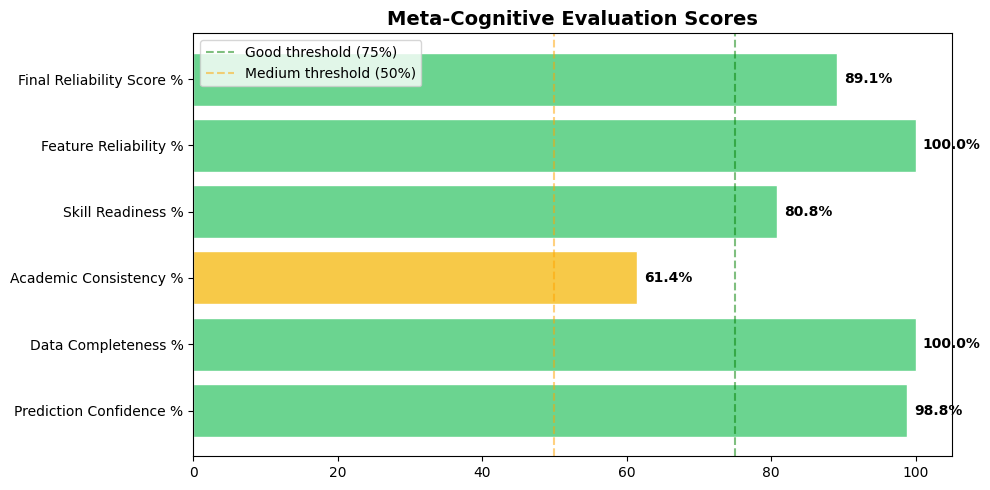

In [13]:
# ── Visualise Meta-Cognitive Scores ─────────────────────────────────────────
labels = list(meta.keys())
values = list(meta.values())
colors = ['#6BD490' if v >= 75 else '#F7C948' if v >= 50 else '#F7644F' for v in values]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(labels, values, color=colors, edgecolor='white')
ax.set_xlim(0, 105)
ax.axvline(75, color='green', linestyle='--', alpha=0.5, label='Good threshold (75%)')
ax.axvline(50, color='orange', linestyle='--', alpha=0.5, label='Medium threshold (50%)')
for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
ax.set_title('Meta-Cognitive Evaluation Scores', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


## 9. 💡 Recommendation Engine

In [14]:
def generate_recommendations(inp, drop_pct, place_pct):
    recs = []
    if float(inp.get('attendance',75)) < 75:
        recs.append(("📉 Low Attendance",
                     "Aim for ≥75% attendance. Regular presence strongly reduces dropout risk."))
    if float(inp.get('cgpa',7)) < 6.5:
        recs.append(("📚 Low CGPA",
                     "Focus on weak subjects. Seek tutoring and revise fundamentals."))
    if int(inp.get('backlogs',0)) > 0:
        recs.append(("⚠️ Backlogs",
                     f"Clear {inp['backlogs']} backlog(s) this semester."))
    if float(inp.get('coding_skill',60)) < 55:
        recs.append(("💻 Weak Coding", "Practice on LeetCode/HackerRank daily."))
    if float(inp.get('communication_skill',60)) < 55:
        recs.append(("🗣️ Communication", "Join debate club or do mock GDs."))
    if float(inp.get('technical_skill',60)) < 55:
        recs.append(("🔧 Technical Skill", "Build domain projects and follow crash courses."))
    if int(inp.get('internship',0)) == 0:
        recs.append(("🏢 No Internship", "Apply on Internshala or LinkedIn — even 1 month counts."))
    if int(inp.get('projects',0)) < 1:
        recs.append(("🛠️ No Projects", "Build one end-to-end project and host on GitHub."))
    if int(inp.get('certifications',0)) == 0:
        recs.append(("🎓 No Certs", "Complete an NPTEL / Coursera / Google certificate."))
    if place_pct < 50:
        recs.append(("📝 Low Placement", "Improve resume, LinkedIn, and do mock interviews."))
    if drop_pct > 60:
        recs.append(("🆘 High Dropout Risk", "Talk to your academic advisor immediately."))
    if not recs:
        recs.append(("✅ Great Profile!", "Keep up excellent work. Consider research or higher studies."))
    return recs

recs = generate_recommendations(student, drop_prob*100, place_prob*100)
print("\n📋 PERSONALISED RECOMMENDATIONS")
print("="*55)
for issue, advice in recs:
    print(f"\n  {issue}")
    print(f"  → {advice}")
print("="*55)



📋 PERSONALISED RECOMMENDATIONS

  ✅ Great Profile!
  → Keep up excellent work. Consider research or higher studies.


---
## ✅ Project Summary

| Component | Details |
|-----------|---------|
| **Models** | Logistic Regression, Decision Tree, Random Forest, XGBoost, Hard Voting, Soft Voting |
| **Selection** | Auto-selected by F1 Score |
| **Novel Module** | Meta-Cognitive Evaluation (5 reliability sub-scores) |
| **Tasks** | Dropout Risk + Placement Probability (dual-head) |
| **Recommendations** | Rule-based, personalised per student |

### Extending to a Conference Paper
- Replace synthetic data with real UCI/Kaggle dataset
- Add SHAP explainability alongside meta-cognitive scores
- Run ablation study: impact of meta-cognitive filtering on user trust
- Compare with baseline lacking reliability evaluation layer
